# Projeto: Monitor de Sentimento do COPOM via NLP
Este notebook automatiza a coleta e análise das atas do Comitê de Política Monetária (COPOM) do Banco Central do Brasil. O objetivo é transformar textos brutos em indicadores quantitativos de incerteza e estabilidade.

### 🛠 Instalação de Dependências
Instalamos as bibliotecas necessárias para:
* **Extração de Dados**: `pdfplumber` e `requests`.
* **NLP & Estatística**: `nltk`, `scikit-learn` e `wordcloud`.
* **Visualização**: `matplotlib`.

In [ ]:
%pip install requests pandas pdfplumber nltk wordcloud matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.
Ambiente inicializado com as ferramentas do Colab!


## 1. Extração Automatizada (Scraping)
Nesta etapa, utilizamos a API oficial do Banco Central para localizar os PDFs das atas mais recentes. 
* O script baixa o arquivo em memória.
* Extrai o texto de todas as páginas.
* Consolida tudo em um **DataFrame do Pandas** (nosso Corpus de pesquisa).

In [4]:
import requests
import pandas as pd
import pdfplumber
import io
import warnings
import time

warnings.filterwarnings('ignore')

class CopomBulkScraper:
    def __init__(self, qtd_atas=10):
        self.api_url = f"https://www.bcb.gov.br/api/servico/sitebcb/atascopom/ultimas?quantidade={qtd_atas}&filtro="
        self.headers = {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
            "Referer": "https://www.bcb.gov.br/publicacoes/atascopom"
        }

    def obter_dataframe_completo(self):
        print(f"⏳ Acessando API para buscar as últimas atas...")
        response = requests.get(self.api_url, headers=self.headers, verify=False)
        if response.status_code != 200:
            return None

        dados = response.json().get('conteudo', [])
        df = pd.DataFrame(dados)
        df['link_pdf'] = "https://www.bcb.gov.br" + df['Url']
        df['texto_integral'] = ""

        print(f"✅ Encontradas {len(df)} atas. Iniciando extração de texto...")
        for index, row in df.iterrows():
            print(f"📦 Processando: {row['Titulo']}")
            df.at[index, 'texto_integral'] = self._baixar_e_extrair(row['link_pdf'])
            time.sleep(1)
        return df[['Titulo', 'DataReferencia', 'texto_integral', 'link_pdf']]

    def _baixar_e_extrair(self, url):
        try:
            res = requests.get(url, headers=self.headers, verify=False)
            with pdfplumber.open(io.BytesIO(res.content)) as pdf:
                return "\n".join([pagina.extract_text() for pagina in pdf.pages if pagina.extract_text()])
        except:
            return "ERRO"

scraper = CopomBulkScraper(qtd_atas=10)
df_copom = scraper.obter_dataframe_completo()
display(df_copom.head())

⏳ Acessando API para buscar as últimas atas...
✅ Encontradas 10 atas. Iniciando extração de texto...
📦 Processando: 276ª Reunião - 27-28 janeiro, 2026
📦 Processando: 275ª Reunião - 9-10 dezembro, 2025
📦 Processando: 274ª Reunião - 4-5 novembro, 2025
📦 Processando: 273ª Reunião - 16-17 setembro, 2025
📦 Processando: 272ª Reunião - 29-30 julho, 2025
📦 Processando: 271ª Reunião - 17-18 junho, 2025
📦 Processando: 270ª Reunião - 6-7 maio, 2025
📦 Processando: 269ª Reunião - 18-19 março, 2025
📦 Processando: 268ª Reunião - 28-29 janeiro, 2025
📦 Processando: 267ª Reunião - 10-11 dezembro, 2024


,Titulo,DataReferencia,texto_integral,link_pdf
0,"276ª Reunião - 27-28 janeiro, 2026",2026-01-28T03:00:00Z,276ª\nAta da Reunião do\nComitê de Política Mo...,https://www.bcb.gov.br/content/copom/atascopom...
1,"275ª Reunião - 9-10 dezembro, 2025",2025-12-10T03:00:00Z,275ª\nAta da Reunião do\nComitê de Política Mo...,https://www.bcb.gov.br/content/copom/atascopom...
2,"274ª Reunião - 4-5 novembro, 2025",2025-11-05T03:00:00Z,274ª\nAta da Reunião do\nComitê de Política Mo...,https://www.bcb.gov.br/content/copom/atascopom...
3,"273ª Reunião - 16-17 setembro, 2025",2025-09-17T03:00:00Z,273ª\nAta da Reunião do\nComitê de Política Mo...,https://www.bcb.gov.br/content/copom/atascopom...
4,"272ª Reunião - 29-30 julho, 2025",2025-07-30T03:00:00Z,272ª\nAta da Reunião do\nComitê de Política Mo...,https://www.bcb.gov.br/content/copom/atascopom...


## 2. Nível 1: Análise Visual (Nuvem de Palavras)
A primeira camada de análise foca na **frequência de termos**. 
* **Stopwords**: Removemos palavras irrelevantes (artigos, preposições) e termos técnicos de rodapé.
* **Insight**: O tamanho da palavra na nuvem indica sua dominância no discurso daquela reunião específica.

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ddom1\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Zip Slip blocked: stopwords/


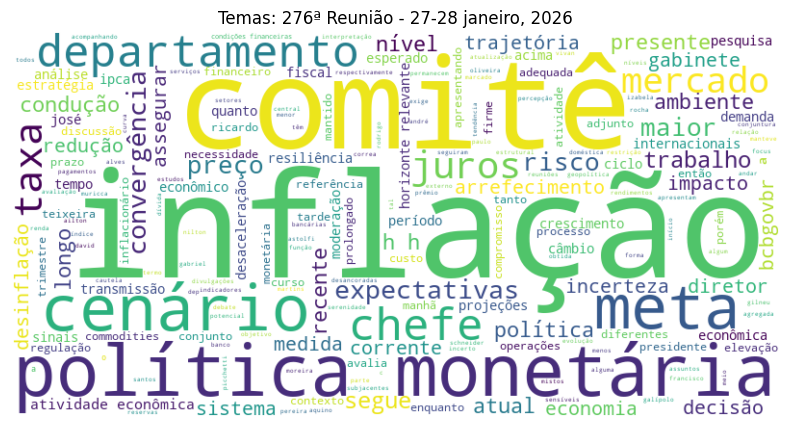

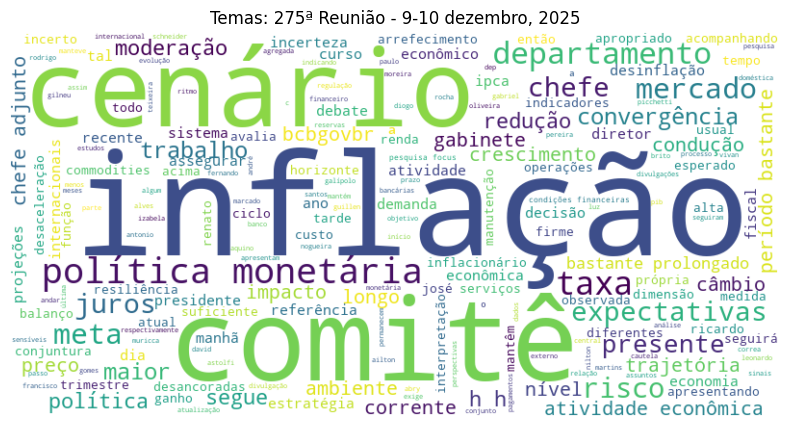

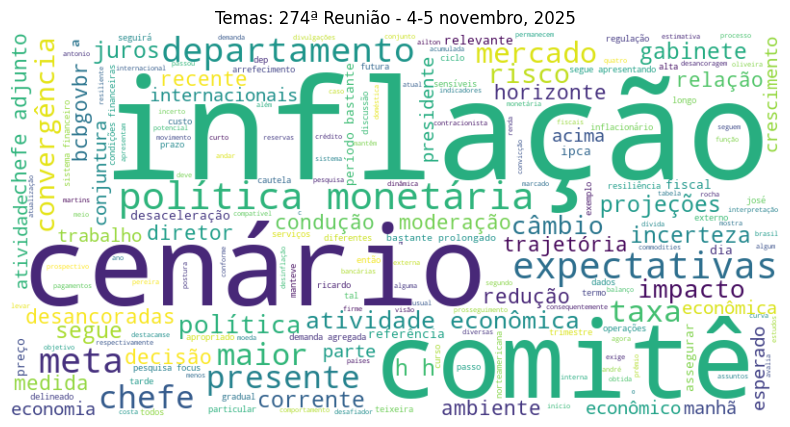

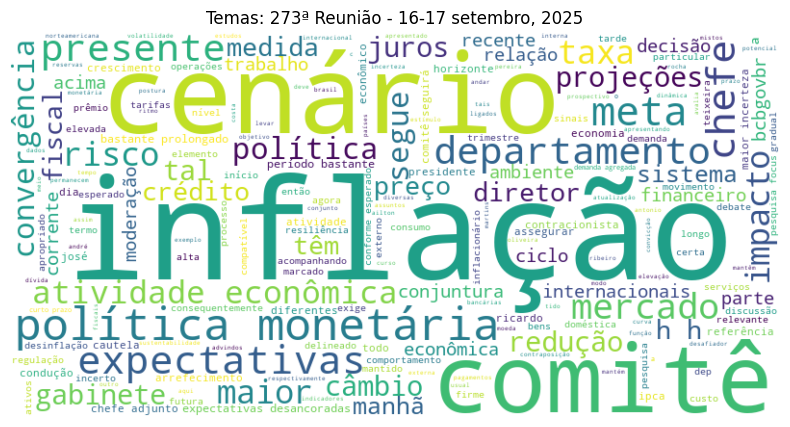

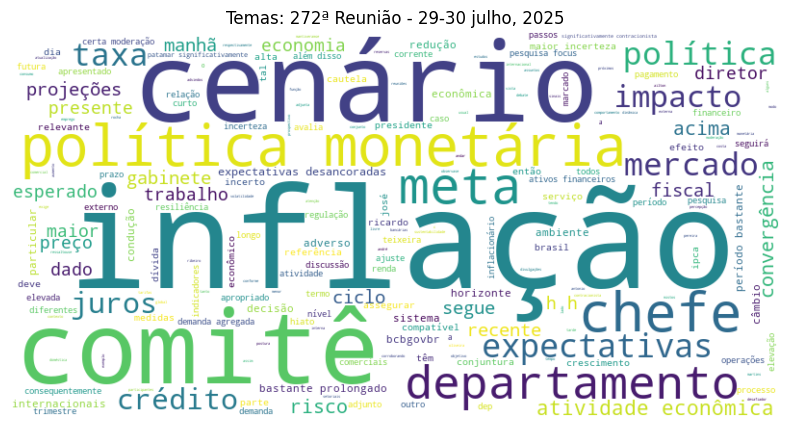

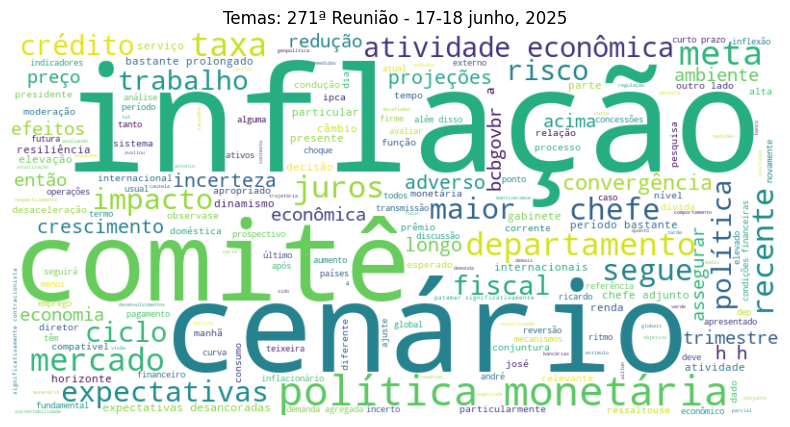

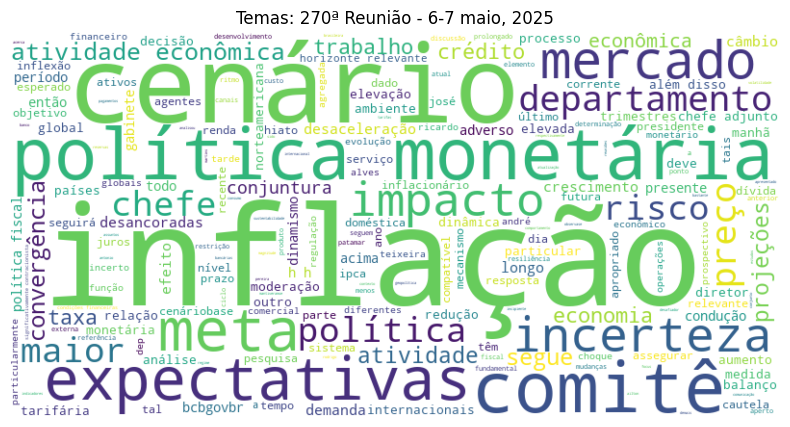

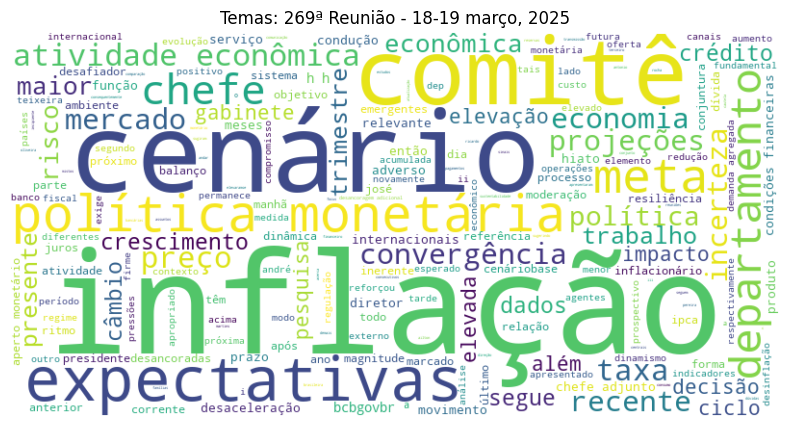

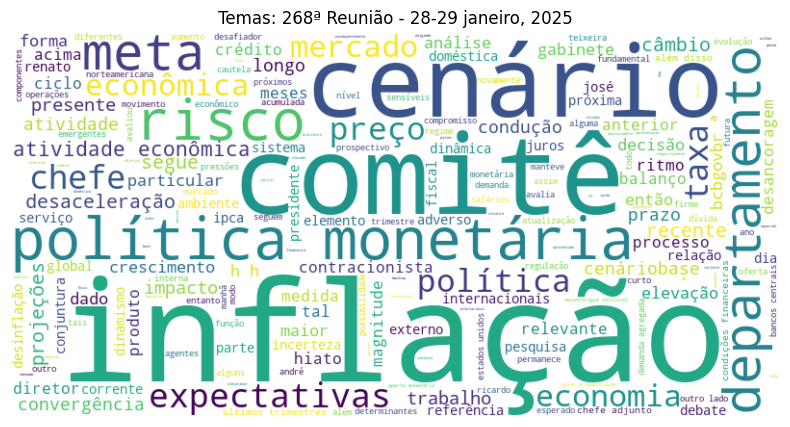

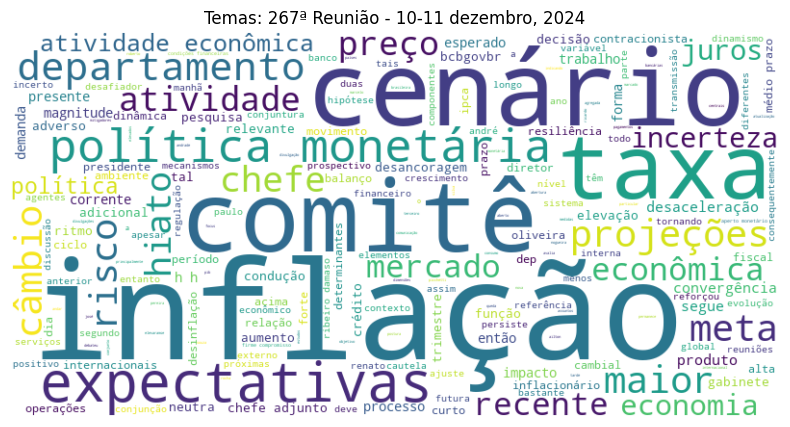

In [5]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
import re

nltk.download('stopwords')
stop_words = set(stopwords.words('portuguese'))
stop_words.update(['reunião', 'copom', 'ata', 'bcb', 'membros', 'sobre', 'ainda', 'pode', 'janeiro', 'fevereiro', 'março', 'abril', 'maio', 'junho', 'julho', 'agosto', 'setembro', 'outubro', 'novembro', 'dezembro'])

def gerar_nuvens(df):
    for index, row in df.iterrows():
        texto_limpo = re.sub(r'[^\w\s]', '', row['texto_integral'].lower())
        texto_limpo = re.sub(r'\d+', '', texto_limpo)
        wc = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words, colormap='viridis').generate(texto_limpo)
        plt.figure(figsize=(10, 5))
        plt.imshow(wc, interpolation='bilinear')
        plt.title(f"Temas: {row['Titulo']}")
        plt.axis('off')
        plt.show()

gerar_nuvens(df_copom)

## 3. Nível 2: Índice de Incerteza Léxico
Aqui aplicamos o conceito de **Análise Léxica de Sentimento**. 
* Criamos um dicionário de termos que indicam cautela ou dúvida (Ex: *risco, volatilidade, incerteza*).
* O índice é **normalizado**: calculamos a porcentagem de palavras de incerteza em relação ao total de palavras da ata.
* **Resultado**: Um gráfico que mostra a "temperatura" da preocupação do Banco Central ao longo do tempo.

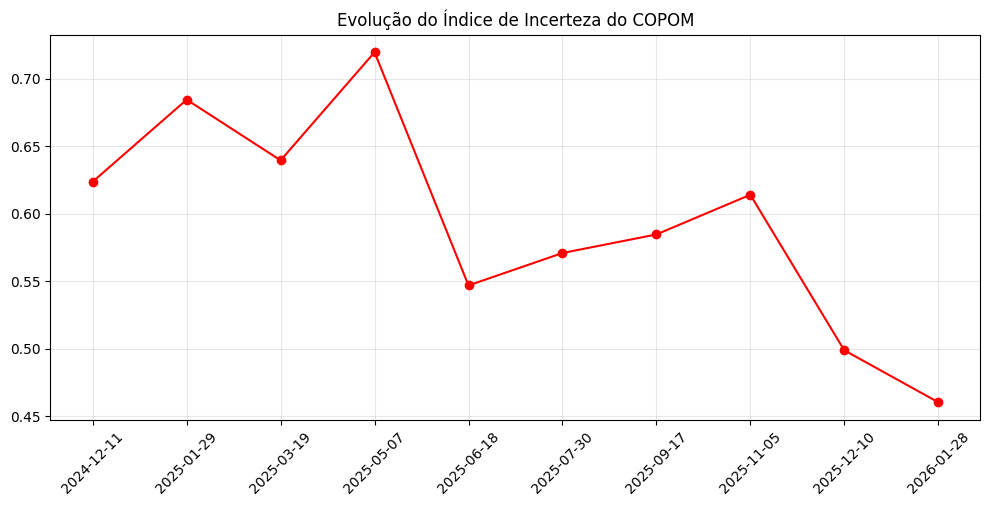

In [6]:
termos_incerteza = ['incerteza', 'incertezas', 'risco', 'riscos', 'duvida', 'volatilidade', 'cautela', 'dependente']

def calcular_incerteza(texto):
    palavras = texto.lower().split()
    contagem = sum(palavras.count(termo) for termo in termos_incerteza)
    return (contagem / len(palavras)) * 100 if len(palavras) > 0 else 0

df_copom['indice_incerteza'] = df_copom['texto_integral'].apply(calcular_incerteza)
df_plot = df_copom.iloc[::-1]

plt.figure(figsize=(12, 5))
plt.plot(df_plot['DataReferencia'].str[:10], df_plot['indice_incerteza'], marker='o', color='red')
plt.title('Evolução do Índice de Incerteza do COPOM')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

## 4. Nível 3: Contexto e Bigramas (N-Grams)
Palavras soltas podem enganar. Para entender o contexto real, analisamos **duplas de palavras (Bigramas)**.
* **Foco**: O robô identifica o que acompanha as palavras-chave (Ex: "Risco *Fiscal*" vs "Risco *Externo*").
* **Aplicação**: Isso revela quais são os temas específicos que estão gerando os picos de incerteza detectados no nível anterior.

In [7]:
from nltk.util import ngrams
from collections import Counter

def caçador_de_riscos(df):
    todas_as_duplas = []
    for texto in df['texto_integral']:
        palavras = [p for p in re.sub(r'[^\w\s]', '', texto.lower()).split() if p not in stop_words]
        todas_as_duplas.extend(list(ngrams(palavras, 2)))
    
    riscos = [bg for bg in todas_as_duplas if bg[0] in ['risco', 'incerteza', 'cenário']]
    return Counter(riscos).most_common(10)

print("🔍 Riscos e Cenários Reais Detectados:")
for r, freq in caçador_de_riscos(df_copom):
    print(f"{r[0]} {r[1]}: {freq} vezes")

🔍 Riscos e Cenários Reais Detectados:
cenário referência: 36 vezes
cenário inflação: 32 vezes
cenário maior: 19 vezes
cenário externo: 18 vezes
cenário prospectivo: 16 vezes
cenário inflacionário: 11 vezes
cenário esperado: 11 vezes
cenário internacional: 11 vezes
cenário copom1: 10 vezes
cenário doméstico: 10 vezes


## 5. Nível 4: Estabilidade de Discurso (Similaridade)
O teste final de rigor. Utilizamos **Similaridade de Cosseno** e vetores **TF-IDF** para comparar matematicamente a ata atual com a anterior.
* **Estabilidade (> 90%)**: O discurso é mantido, sinalizando previsibilidade.
* **Ruptura (< 85%)**: O Banco Central alterou significativamente a redação, o que geralmente precede mudanças na trajetória da taxa Selic.

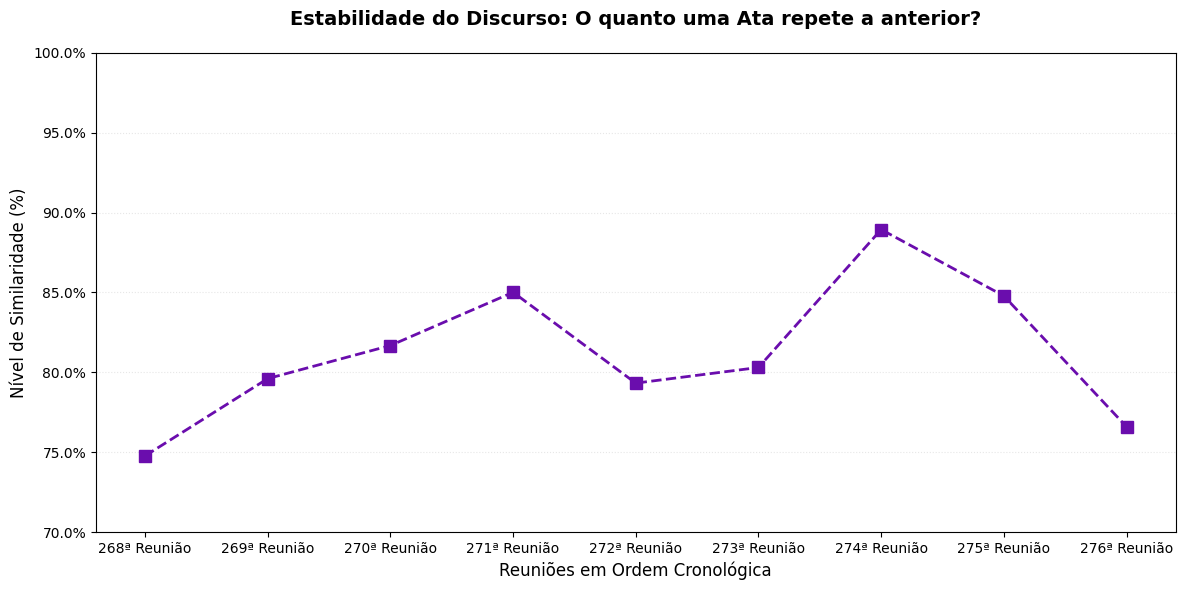

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.ticker as mtick # Para formatar porcentagem

# 1. Vetorização e Similaridade (Mantemos a lógica)
vectorizer = TfidfVectorizer(stop_words=list(stop_words))
tfidf_matrix = vectorizer.fit_transform(df_copom['texto_integral'])

textos_inv = df_copom['texto_integral'].iloc[::-1].values
titulos_inv = df_copom['Titulo'].iloc[::-1].values
similaridades = []

for i in range(len(textos_inv) - 1):
    sim = cosine_similarity(tfidf_matrix[len(textos_inv)-1-i], tfidf_matrix[len(textos_inv)-2-i])[0][0]
    similaridades.append(sim)

# 2. Plotagem Melhorada
plt.figure(figsize=(12, 6))
ax = plt.gca()

# Criamos labels curtos para o Eixo X (ex: "268ª") para não sobrepor
labels_curtos = [t.split('-')[0].strip() for t in titulos_inv[1:]]

plt.plot(labels_curtos, similaridades, marker='s', color='#6A0DAD', linestyle='--', linewidth=2, markersize=8)

# --- MELHORIAS NO EIXO Y ---
plt.ylim(0.7, 1.0) # Mantém o foco no topo
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)) # Transforma 0.85 em 85%

# --- ESTÉTICA ---
plt.title('Estabilidade do Discurso: O quanto uma Ata repete a anterior?', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Nível de Similaridade (%)', fontsize=12)
plt.xlabel('Reuniões em Ordem Cronológica', fontsize=12)
plt.grid(True, axis='y', alpha=0.3, linestyle=':') # Grade leve apenas no Y para facilitar leitura
plt.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()
plt.show()